In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Importing Required Libraries

In this step, I imported all the required libraries for the project. Pandas and NumPy are used for data handling and numerical operations. Matplotlib and Seaborn help in creating graphs and visualizing the data. The Scikit-learn libraries are used for data preprocessing, building machine learning models, tuning the models using GridSearchCV, and evaluating their performance using different metrics like MAE, RMSE, and R² Score.

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
# Display the first 5 rows
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Loading the Dataset

In this step, I loaded the Tesla deliveries dataset into a Pandas DataFrame using the `read_csv()` function.

In [3]:
# Shape of the dataset
print("Shape of the Dataset:", df.shape)
# Column names
print("\nColumn Names:")
print(df.columns)
# Dataset information
print("\nDataset Information:")
df.info()
# Statistical summary
print("\nStatistical Summary:")
df.describe()

Shape of the Dataset: (2640, 12)

Column Names:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Understanding the Dataset

After loading the dataset, I explored its basic details to understand its structure.I checked the shape of the dataset to know the number of rows and columns, viewed the column names, examined the data types and missing values using `info()`, and generated the statistical summary using `describe()`. This helped me understand the dataset before starting the preprocessing and analysis.

In [4]:
# Check missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())
# Total missing values
print("\nTotal Missing Values:", df.isnull().sum().sum())
# Check duplicate rows
print("\nNumber of Duplicate Rows:", df.duplicated().sum())

Missing Values in Each Column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Total Missing Values: 0

Number of Duplicate Rows: 0


## Checking Data Quality

Before performing any analysis, I checked the dataset for missing values and duplicate records. Missing values can affect the performance of machine learning models, while duplicate rows can lead to incorrect analysis.

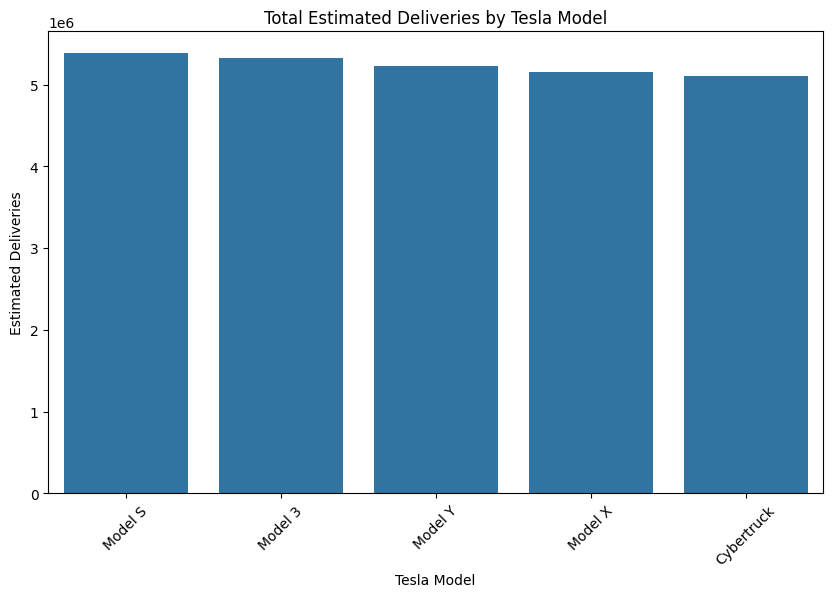

In [5]:
# Total deliveries by model
model_deliveries = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=model_deliveries.index, y=model_deliveries.values)
plt.title("Total Estimated Deliveries by Tesla Model")
plt.xlabel("Tesla Model")
plt.ylabel("Estimated Deliveries")
plt.xticks(rotation=45)
plt.show()

## Exploratory Data Analysis: Deliveries by Tesla Model

In this step, I analyzed the total estimated deliveries for each Tesla model by grouping the data based on the model name. I then created a bar chart to compare the delivery performance of different models. This visualization helped me identify which Tesla models had the highest and lowest estimated deliveries and understand the overall distribution of deliveries across all models.

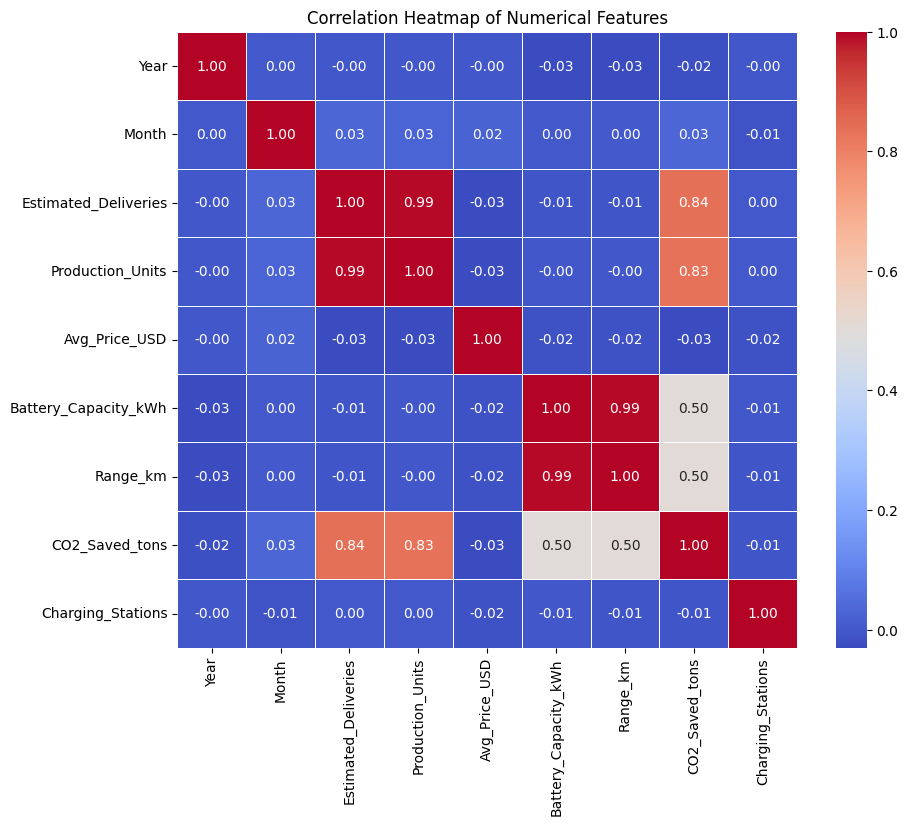

In [6]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])
# Create correlation matrix
correlation_matrix = numeric_df.corr()
# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Exploratory Data Analysis: Correlation Heatmap

In this step, I selected only the numerical columns from the dataset and calculated the correlation between them. I then used a heatmap to visualize these relationships. This made it easier to understand how strongly different features are related to each other and identify both positive and negative correlations. The heatmap also helped me decide which features could be useful for building the machine learning models.

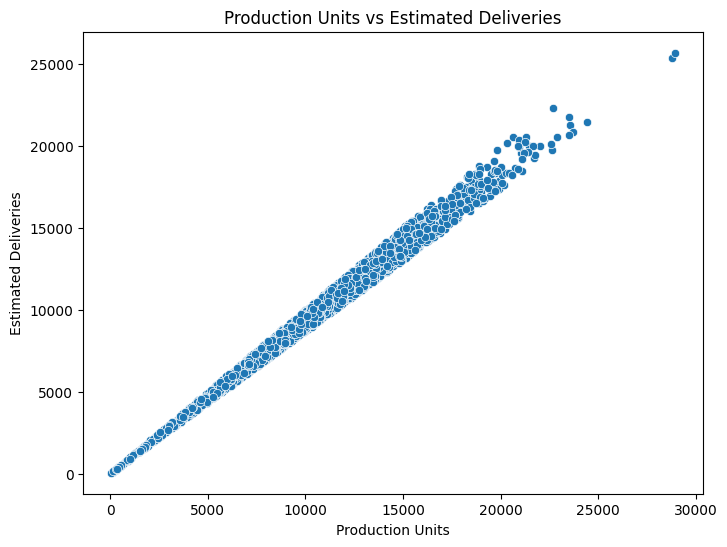

In [7]:
# Scatter plot between Production Units and Estimated Deliveries
plt.figure(figsize=(8,6))
sns.scatterplot(x='Production_Units',
                y='Estimated_Deliveries',
                data=df)
plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.show()

## Exploratory Data Analysis: Production Units vs Estimated Deliveries

In this step, I created a scatter plot to understand the relationship between production units and estimated deliveries. This graph helped me observe whether an increase in production leads to an increase in deliveries. By looking at the distribution of the points, I could identify the overall trend and check if there were any unusual values or outliers in the data.

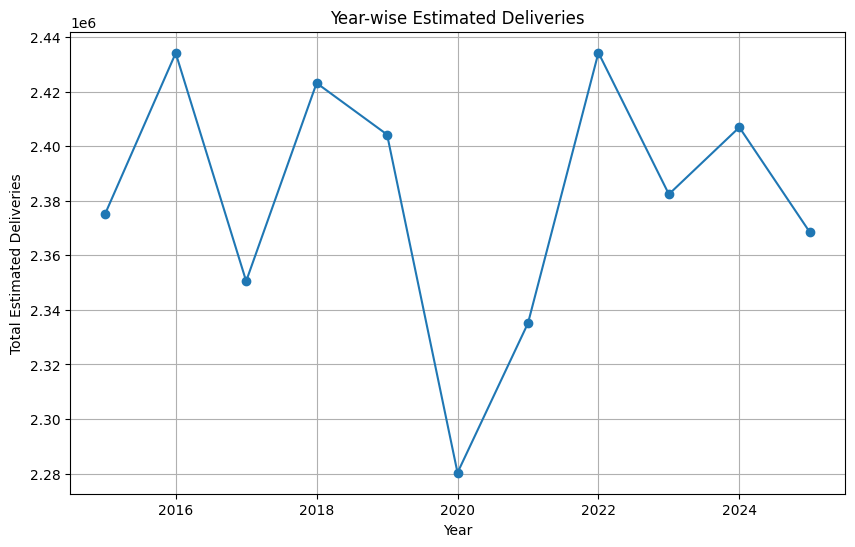

In [8]:
# Calculate yearly deliveries
yearly_deliveries = df.groupby('Year')['Estimated_Deliveries'].sum()
# Plot line chart
plt.figure(figsize=(10,6))

plt.plot(yearly_deliveries.index,
         yearly_deliveries.values,
         marker='o')
plt.title("Year-wise Estimated Deliveries")
plt.xlabel("Year")
plt.ylabel("Total Estimated Deliveries")
plt.grid(True)
plt.show()

## Exploratory Data Analysis: Year-wise Estimated Deliveries

In this step, I grouped the data by year and calculated the total estimated deliveries for each year. I then plotted a line chart to observe how the deliveries changed over time. This visualization helped me understand the overall trend, identify periods of growth or decline, and see how Tesla's estimated deliveries varied from year to year.

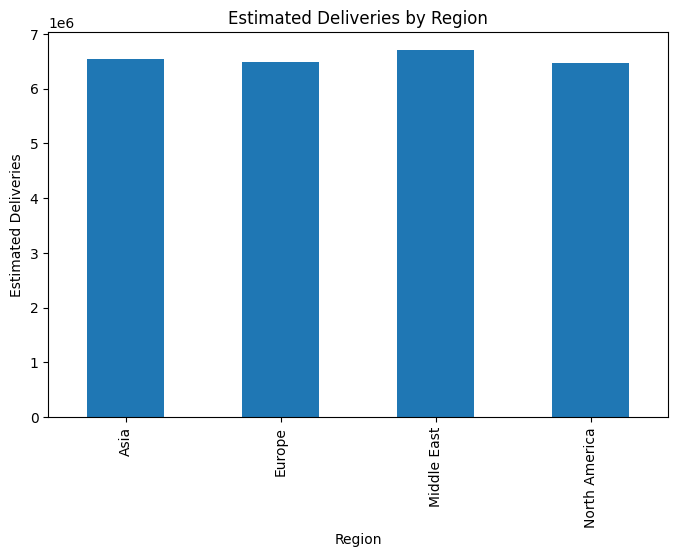

In [9]:
region_deliveries = df.groupby('Region')['Estimated_Deliveries'].sum()
plt.figure(figsize=(8,5))
region_deliveries.plot(kind='bar')
plt.title("Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")
plt.show()

## Exploratory Data Analysis: Estimated Deliveries by Region

In this step, I grouped the dataset based on different regions and calculated the total estimated deliveries for each region. I then created a bar chart to compare the delivery performance across all regions. This visualization helped me understand which regions contributed the most to Tesla's estimated deliveries and made it easier to compare the overall delivery distribution between different regions.

In [10]:
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder
# Create LabelEncoder object
encoder = LabelEncoder()
# Encode categorical columns
df['Region'] = encoder.fit_transform(df['Region'])
df['Model'] = encoder.fit_transform(df['Model'])
df['Source_Type'] = encoder.fit_transform(df['Source_Type'])
# Display first five rows
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


## Encoding Categorical Features

In this step, I converted the categorical columns into numerical values using the LabelEncoder technique. Machine learning algorithms cannot work directly with text data, so encoding is an important preprocessing step. I encoded the `Region`, `Model`, and `Source_Type` columns and then displayed the first few rows to verify that the transformation was applied correctly.

In [11]:
# Features and Target
X = df.drop(columns=['Estimated_Deliveries'])
y = df['Estimated_Deliveries']
# Chronological Split (80-20)
split_index = int(len(df) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]
# Train Model
lr = LinearRegression()
lr.fit(X_train, y_train)
# Prediction
y_pred = lr.predict(X_test)
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("RMSE :", rmse)
print("R² Score :", r2)

MAE : 310.9781976269299
RMSE : 376.681631811692
R² Score : 0.9907511023766586


## Training and Evaluating the Linear Regression Model

In this step, I selected the input features and the target variable from the dataset. Instead of using a random train-test split, I divided the data chronologically into 80% training data and 20% testing data so that the model learns from past records and predicts future values. After training the Linear Regression model, I evaluated its performance using MAE, RMSE, and R² Score. These evaluation metrics helped me understand how accurately the model predicts the estimated deliveries.

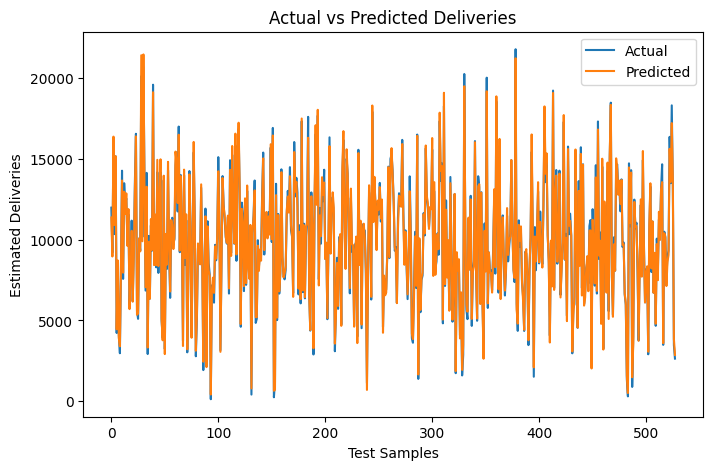

In [12]:
plt.figure(figsize=(8,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title("Actual vs Predicted Deliveries")
plt.xlabel("Test Samples")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.show()

## Actual vs Predicted Deliveries Comparison

After training the Linear Regression model, I plotted the actual and predicted delivery values for the test dataset. This graph helped me visually compare the model's predictions with the actual values. If the predicted line follows the actual line closely, it indicates that the model is making accurate predictions. This visualization also made it easier to identify any differences or prediction errors.

In [13]:
# Import cross validation function
from sklearn.model_selection import cross_val_score
# Create Linear Regression model
linear_model = LinearRegression()
# Perform 5-Fold Cross Validation using R² score
cv_scores = cross_val_score(
    linear_model,
    X,
    y,
    cv=5,
    scoring='r2'
)
# Print R² score of each fold
print("R² Score for each fold:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")
# Print average R² score
print("\nAverage R² Score:", round(cv_scores.mean(), 4))

R² Score for each fold:
Fold 1: 0.9907
Fold 2: 0.9904
Fold 3: 0.9893
Fold 4: 0.9904
Fold 5: 0.9908

Average R² Score: 0.9903


## 5-Fold Cross Validation

In this step, I used 5-Fold Cross Validation to check how well the Linear Regression model performs on different parts of the dataset. The dataset is divided into five equal parts, and the model is trained and tested five times by using a different part as the test set each time. I printed the R² score for every fold and also calculated the average R² score to get an overall idea of the model's performance and consistency.

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train Random Forest Model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
# Prediction
rf_pred = rf_model.predict(X_test)
# Evaluation
mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)
print("Random Forest Performance")
print("MAE :", mae)
print("RMSE :", rmse)
print("R² Score :", r2)

Random Forest Performance
MAE : 297.2527083333333
RMSE : 379.8465195040703
R² Score : 0.9905950305610248


## Training and Evaluating the Random Forest Model

In this step, I trained a Random Forest Regressor to predict the estimated deliveries. Unlike Linear Regression, Random Forest combines multiple decision trees to make more accurate and reliable predictions. After training the model, I predicted the delivery values for the test dataset and evaluated its performance using MAE, RMSE, and R² Score. These metrics helped me understand how well the Random Forest model performed on the unseen data.

In [15]:
from sklearn.model_selection import GridSearchCV
# Hyperparameter Grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
# Best Model
best_rf = grid_search.best_estimator_
# Prediction
best_pred = best_rf.predict(X_test)
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)
# Evaluation
print("\nEvaluation After GridSearch")
print("MAE :", mean_absolute_error(y_test, best_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, best_pred)))
print("R² Score :", r2_score(y_test, best_pred))

Best Parameters: {'max_depth': None, 'n_estimators': 50}
Best CV Score: 0.9888919038092194

Evaluation After GridSearch
MAE : 298.53310606060603
RMSE : 380.83615834307955
R² Score : 0.9905459599637941


## Hyperparameter Tuning using GridSearchCV

In this step, I used GridSearchCV to improve the performance of the Random Forest model by finding the best combination of hyperparameters. I tested different values of `n_estimators` and `max_depth` using 5-fold cross-validation. After identifying the best parameters, I trained the optimized model, made predictions on the test data, and evaluated its performance using MAE, RMSE, and R² Score. This helped me compare the optimized model with the default Random Forest model and check whether the tuning improved the prediction accuracy.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
# Create DataFrame for feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})
# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
# Display Top 10 Features
print("Top 10 Feature Importances:")
print(feature_importance.head(10))

Top 10 Feature Importances:
              Feature  Importance
4    Production_Units    0.990370
8      CO2_Saved_tons    0.002441
7            Range_km    0.001615
5       Avg_Price_USD    0.001309
10  Charging_Stations    0.001196
0                Year    0.000925
1               Month    0.000805
3               Model    0.000466
2              Region    0.000383
9         Source_Type    0.000309


## Feature Importance Analysis

In this step, I checked the importance of each feature used by the optimized Random Forest model. Feature importance shows how much each feature contributes to predicting the target variable. I sorted the features based on their importance scores and displayed the top 10 most important ones. This helped me understand which features had the greatest influence on the model's predictions.

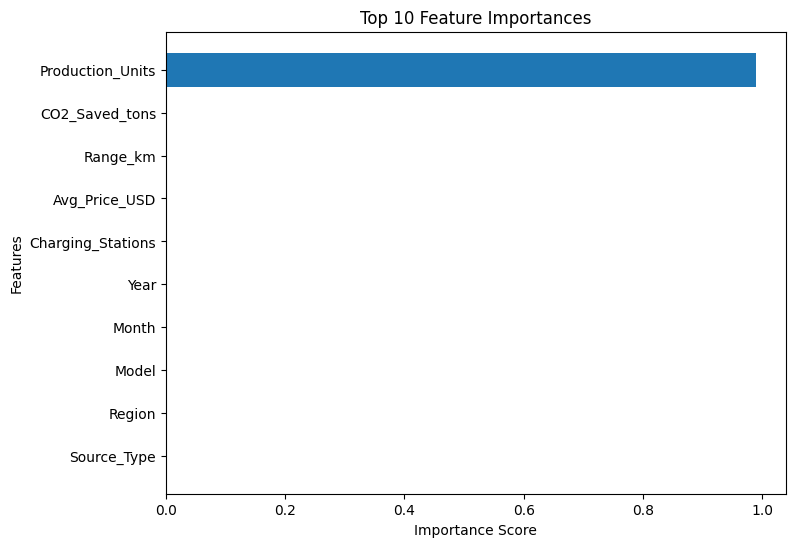

In [17]:
# Plot Top 10 Feature Importances
top10 = feature_importance.head(10)
plt.figure(figsize=(8,6))
plt.barh(top10['Feature'], top10['Importance'])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

## Visualizing the Top 10 Important Features

In this step, I created a horizontal bar chart to visualize the top 10 most important features identified by the optimized Random Forest model. The chart makes it easier to compare the importance scores of different features and quickly identify which ones have the greatest impact on predicting the estimated deliveries. This visualization also helps in understanding the factors that influence the model's predictions the most.

In [18]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Estimated_Deliveries'])

print("ADF Statistic :", result[0])
print("p-value :", result[1])

if result[1] < 0.05:
    print("Interpretation: Since p-value < 0.05, the time series is Stationary.")
else:
    print("Interpretation: Since p-value >= 0.05, the time series is NOT Stationary.")

ADF Statistic : -53.82661259715622
p-value : 0.0
Interpretation: Since p-value < 0.05, the time series is Stationary.


## Stationarity Test using the ADF Test

In this step, I performed the Augmented Dickey-Fuller (ADF) test to check whether the `Estimated_Deliveries` time series is stationary or not. The p-value obtained from the test helps determine the result. If the p-value is less than 0.05, the data is considered stationary; otherwise, it is non-stationary. This test is useful before performing time series forecasting because many forecasting techniques work better with stationary data.

In [19]:
forecast = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': rf_pred
})

forecast['Error %'] = (
    abs(forecast['Actual'] - forecast['Predicted'])
    / forecast['Actual']
) * 100

print("Forecast Table (First 20 Test Records)")
forecast.head(20).round(2)

Forecast Table (First 20 Test Records)


,Actual,Predicted,Error %
0,11974,11305.62,5.58
1,9189,9008.65,1.96
2,15956,16745.93,4.95
3,10336,10864.72,5.12
4,15152,15874.48,4.77
5,4224,3990.37,5.53
6,8475,8857.06,4.51
7,4093,3829.56,6.44
8,2972,3100.07,4.31
9,8208,8399.22,2.33


## Forecast Table Comparison

In this step, I created a forecast table to compare the actual delivery values with the values predicted by the optimized Random Forest model. I also calculated the percentage error for each prediction to measure how close the predicted values are to the actual ones. Displaying the first 20 test records made it easier to evaluate the prediction accuracy and identify the difference between the actual and predicted deliveries.

## Conclusion

In this assignment, I completed an end-to-end machine learning pipeline using the Tesla deliveries dataset. I performed data exploration, preprocessing, feature engineering, and trained both Linear Regression and Random Forest models. I also optimized the Random Forest model using GridSearchCV, analyzed feature importance, performed the ADF stationarity test, and compared the predicted values with the actual values. Overall, this assignment helped me understand the complete workflow of building, evaluating, and improving a machine learning model for prediction tasks.